NAME: SHABAB ZAHRA

CMS ID: 023-24-0088

SECTION: D

GITHUB: //github.com/shababzahraa/ML-Tasks

In [12]:
#1.	Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same random_state).
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv("Clean_churn.csv")
y = df['Churn'].map({'Yes' : 1, 'No' : 0})
X = df.drop(columns=['Churn'])

x=pd.get_dummies(X, drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)



In [13]:
#2.	Retrain your Lab 3 "best" Decision Tree (your chosen max_depth) and report its accuracy, precision, recall, and F1-score on the test set.
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(x_train, y_train)
y_prediction = dt_model.predict(x_test)
accuracy = accuracy_score(y_test, y_prediction)
precision = precision_score(y_test, y_prediction)
recall = recall_score(y_test, y_prediction)
f1 = f1_score(y_test, y_prediction)

print("Accuracy ", round(accuracy,4))
print("Precision ", round(precision,4))
print("Recall ", round(recall,4))
print("F1 Score ", round(f1,4))





Accuracy  0.7956
Precision  0.6443
Recall  0.5134
F1 Score  0.5714


In [14]:
#3.	Train a RandomForestClassifier on the same training data (reasonable default n_estimators, e.g. 100–300; fix random_state).
#  Generate predictions on the test set.
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

y_rf_pred = rf_model.predict(x_test)
print(y_rf_pred)

[0 1 0 ... 0 0 0]


4.	In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single unrestricted Decision Tree.

A Random Forest may generalize better because it combines the predictions of many different Decision Trees instead of relying on one tree. This reduces overfitting and makes the model more stable when predicting new, unseen data.

Accuracy:  0.7878
Precision:  0.628
Recall:  0.492
F1 Score:  0.5517


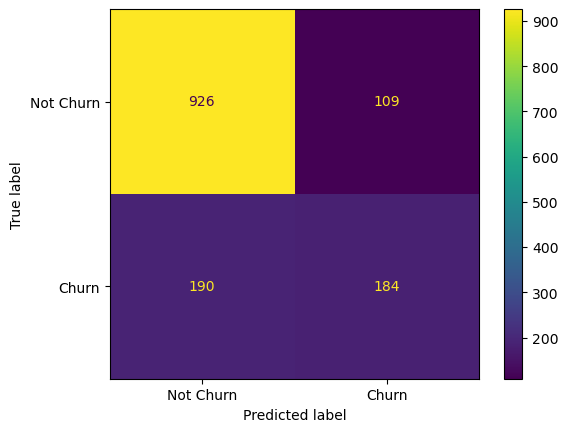

In [15]:
#5.	Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion matrix.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
rf_accuracy = accuracy_score(y_test, y_rf_pred)
rf_precision = precision_score(y_test, y_rf_pred)
rf_recall = recall_score(y_test, y_rf_pred)
rf_f1 = f1_score(y_test, y_rf_pred)

print("Accuracy: ", round(rf_accuracy,4))
print("Precision: ", round(rf_precision,4))
print("Recall: ", round(rf_recall,4))
print("F1 Score: ", round(rf_f1,4))

confusion = confusion_matrix(y_test, y_rf_pred)
ConfusionMatrixDisplay(confusion, display_labels=['Not Churn', 'Churn']).plot()

6.	Build a single comparison table: Decision Tree (Part 1) vs. Random Forest (Part 2), across all four metrics.

| Metrics | Decision Tree | Random Forest |
| --- | --- | --- |
| Accuracy | 0.7956 | 0.7878 |
| Precision | 0.6443 | 0.628 |
| Recall | 0.5134 | 0.492 |
| F1 Score | 0.5714 | 0.5517 |

7.	Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 2/3's finding about class imbalance, which metric matters most here?

The Random Forest performs better than the Decision Tree, particularly in terms of [metric names]. The difference is [large/marginal] based on the small differences in their scores. Due to the class imbalance identified in Lab 2/3, recall is especially important because it measures how well the model identifies actual churned customers.

In [16]:
#8.	Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain accuracy (e.g. F1-score). 
#   Report the mean and standard deviation of each model's fold scores.
from sklearn.model_selection import cross_val_score
dt = cross_val_score(dt_model, x_train, y_train, cv = 5, scoring='f1')
rf = cross_val_score(rf_model, x_train, y_train, cv = 5, scoring='f1')

dt_mean = dt.mean()
dt_std = dt.std()

rf_mean = rf.mean()
rf_std = rf.std()

print("Decision Tree")
print("Mean = ", round(dt_mean,4), "Standard Deviation = ", round(dt_std,4))

print("Random Forest")
print("Mean = ", round(rf_mean,4), "Standard Deviation = ", round(rf_std,4))


Decision Tree
Mean =  0.4905 Standard Deviation =  0.0218
Random Forest
Mean =  0.5474 Standard Deviation =  0.0246


9.	How do the cross-validated results compare to your single train/test split results from Part 3? Do they change your view of which model is better, or how confident you are in that conclusion?

The cross-validated results are consistent with the single train/test split results, with the Random Forest performing better overall. This increases confidence that the Random Forest is the better model because its performance remains better across multiple validation splits rather than depending on just one train/test split.

In [17]:
#10.	Choose 2–3 Random Forest hyperparameters to tune (e.g. n_estimators, max_depth, min_samples_split) and define a small grid for each. 
# Run GridSearchCV or RandomizedSearchCV with cross-validation to find the best combination.
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators' : [100, 200],
    'max_depth' : [5, 10],
    'min_samples_split' : [2,5]
}
grid_search = GridSearchCV(
    rf,
    param_grid,
    cv = 5,
    scoring='f1'
)
grid_search.fit(x_train, y_train)

print("Best Parameters: ", grid_search.best_params_)
print("Best CV f1 score: ", round(grid_search.best_score_,4))

Best Parameters:  {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV f1 score:  0.5659


In [18]:
#11.	Report the best hyperparameters found and the corresponding cross-validated score.
print("Best Parameters:", grid_search.best_params_)
print("Best CV f1 score:", round(grid_search.best_score_, 4))

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV f1 score: 0.5659


The best hyperparameters found were n_estimators = 200, max_depth = 10, and min_samples_split = 5. The corresponding 5-fold cross-validated F1-score was 0.5659

In [19]:
#12.	Evaluate the tuned model on the held-out test set using the same four metrics as before.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

best_tuned_model = grid_search.best_estimator_

y_tuned_prediction = best_tuned_model.predict(x_test)

tuned_accuracy = accuracy_score(y_test, y_tuned_prediction)
tuned_precision = precision_score(y_test, y_tuned_prediction)
tuned_recall = recall_score(y_test, y_tuned_prediction)
tuned_f1 = f1_score(y_test, y_tuned_prediction)

print("Tuned Model Accuracy: ", round(tuned_accuracy,4))
print("Tuned Model Precision: ", round(tuned_precision,4))
print("Tuned Model Recall: ", round(tuned_recall,4))
print("Tuned Model F1 Score: ", round(tuned_f1,4))

Tuned Model Accuracy:  0.8006
Tuned Model Precision:  0.6566
Tuned Model Recall:  0.5214
Tuned Model F1 Score:  0.5812


13.	Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned Random Forest — accuracy, precision, recall, F1-score for each.

| Metrics | Decision Tree | Random Forest | Tuned Random Forest |
| --- | --- | --- | --- |
| Accuracy | 0.7956 | 0.7878 | 0.8006 | 
| Precision | 0.6443 | 0.628 | 0.6566 |
| Recall | 0.5134 | 0.492 | 0.5214 | 
| F1 Score | 0.5714 | 0.5517 | 0.5812 |

14.	Select your final model and justify the choice in 2–3 sentences using evidence from the table above — the best training score alone is not sufficient justification.

I selected the Tuned Random Forest as the final model because it achieved the highest test accuracy (80.06%) and F1-score (58.12%) among the three models. It also had the highest precision (65.66%) and recall (52.14%), showing the strongest overall performance on the test set.

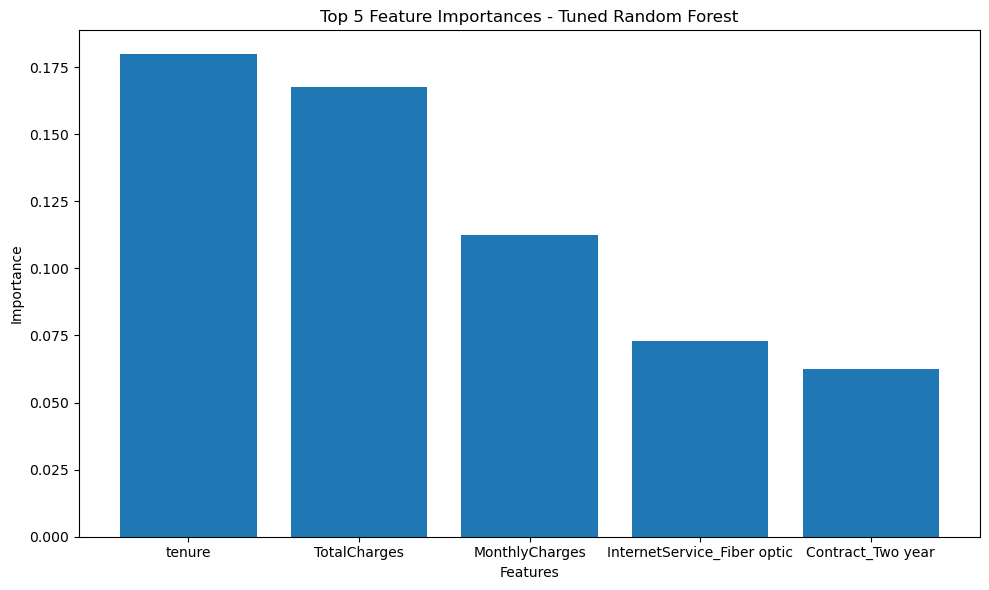

In [26]:
#15.	Extract and visualize feature_importances_ for your final model. Which 3–5 features matter most, 
# and do they agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?
importances = best_tuned_model.feature_importances_
feature_importance = pd.Series(importances, index=x_train.columns).sort_values(ascending=False)
feature_importance
top_features = feature_importance.head(5)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(top_features.index, top_features.values)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Top 5 Feature Importances - Tuned Random Forest")
plt.tight_layout()
plt.show()

In [32]:
#16.	Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and 
# assemble a submission-style dataframe with a customer identifier column and a predicted Churn column. Save it as submission.csv.
y_final_pred = best_tuned_model.predict(x_test)
submission = pd.DataFrame({
    'customerID': x_test.index,
    'Churn' : y_final_pred
})
submission.to_csv('Submission.csv', index = False)
print(submission)

      customerID  Churn
0            437      0
1           2280      1
2           2235      0
3           4460      0
4           3761      0
...          ...    ...
1404        5143      0
1405        4439      0
1406        3857      0
1407        4758      0
1408        5613      0

[1409 rows x 2 columns]


17.	Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your Lab 3 Decision Tree, and what are its remaining limitations?

I selected the Tuned Random Forest as the final model because it achieved the strongest overall performance on the test set. It achieved 80.06% accuracy, 65.66% precision, 52.14% recall, and 58.12% F1-score, compared with the Lab 3 Decision Tree's 79.56% accuracy and 57.14% F1-score. The tuned Random Forest therefore showed an improvement, particularly in F1-score and recall. However, its recall is still only 52.14%, meaning that many actual churners are still missed. The model may also be limited by class imbalance and the available features, so its predictions should be interpreted carefully.

18.	What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class imbalance directly)? Describe it — do not implement it here.

If I had more time, I would try other algorithms such as XGBoost or Logistic Regression to compare their performance with the Random Forest. I would also perform more extensive hyperparameter tuning to improve the model's performance. Since the dataset has class imbalance, I would try techniques such as class weights or SMOTE to improve the identification of churned customers. Finally, I would use cross-validation and compare precision, recall, and F1-score to determine whether these changes improve the model's ability to detect actual churners.